#### Netflix Data Analysis

This project performs Exploratory Data Analysis (EDA) on the Netflix Titles Dataset.

#### Objectives

- Analyze Movies vs TV Shows
- Find top countries producing content
- Analyze ratings
- Analyze content growth over time
- Identify most popular genres

#### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

#### Dataset

This dataset contains information about movies and TV shows available on Netflix, including title, director, cast, country, rating, release year, and genres.

#### Importing necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load Dataset

In [13]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### Basic Information

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [17]:
df.shape  

(8807, 12)

In [18]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

#### Check Missing Values

In [22]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

#### Handle missing values and clean datasets

In [23]:
df["director"] = df["director"].fillna("Unknown")

df["country"] = df["country"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Unknown")

#### Movies and TV Shows

In [24]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

#### Graph for Movies and TV Shows

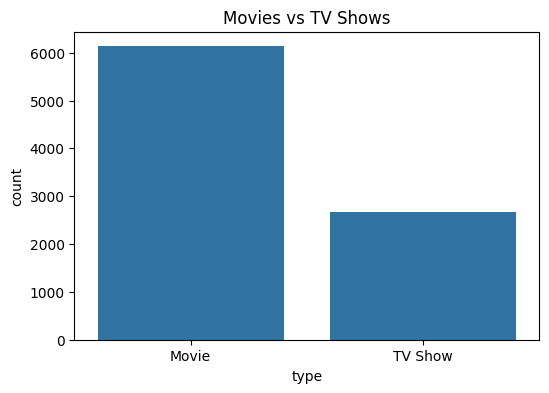

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows")

plt.show()

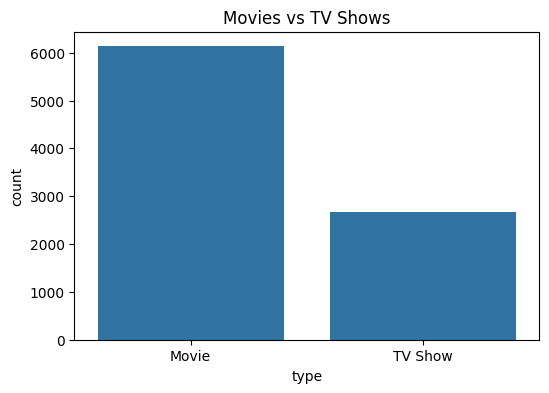

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows")

plt.savefig("images/movies_vs_tvshows.png")

plt.show()

#### Top 10 Countries

In [29]:
top_countries = df["country"].value_counts().head(10)

top_countries

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

#### Graph of Top 10 Countries

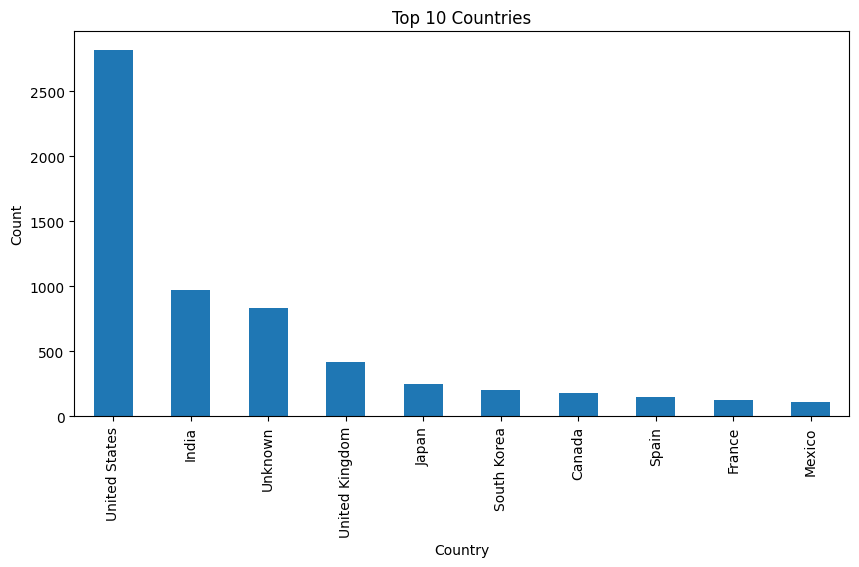

In [37]:
plt.figure(figsize=(10,5))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries")

plt.xlabel("Country")

plt.ylabel("Count")

plt.savefig("images/top_countries.png")

plt.show()

#### Rating Distribution 

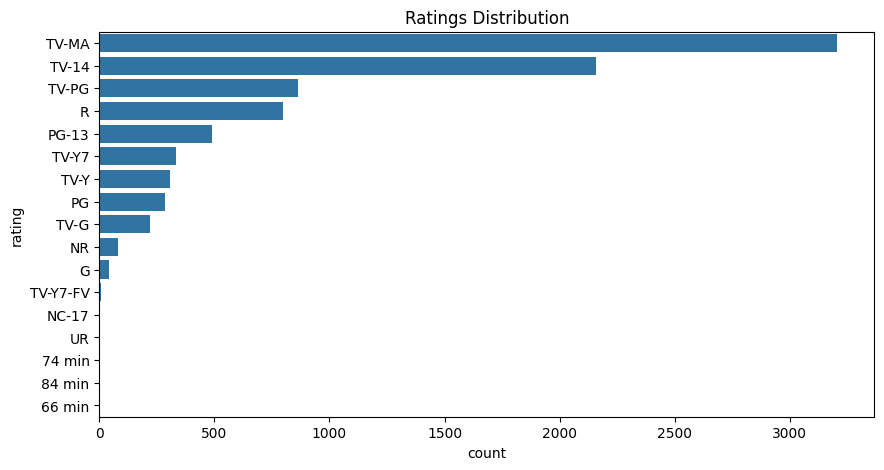

In [38]:
plt.figure(figsize=(10,5))

sns.countplot(
    y=df["rating"],
    order=df["rating"].value_counts().index
)

plt.title("Ratings Distribution")

plt.savefig("images/rating_dist.png")

plt.show()

#### Content Added Every Year 

##### pd.to_datetime() is a Pandas function that converts data into a datetime (date and time) format.

In [32]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [33]:
df["year_added"] = df["date_added"].dt.year

In [34]:
content_per_year = df["year_added"].value_counts().sort_index()

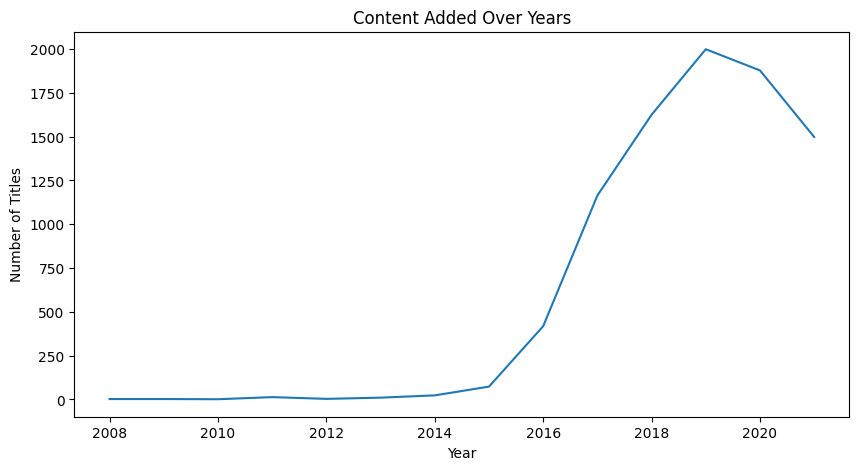

In [39]:
plt.figure(figsize=(10,5))

content_per_year.plot()

plt.title("Content Added Over Years")

plt.xlabel("Year")

plt.ylabel("Number of Titles")

plt.savefig("images/content_added.png")

plt.show()

#### Top 10 Genres

In [40]:
genres = df["listed_in"].str.split(",").explode()

top_genres = genres.value_counts().head(10)

top_genres

listed_in
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64

#### Graph of Top Genres on Netflix

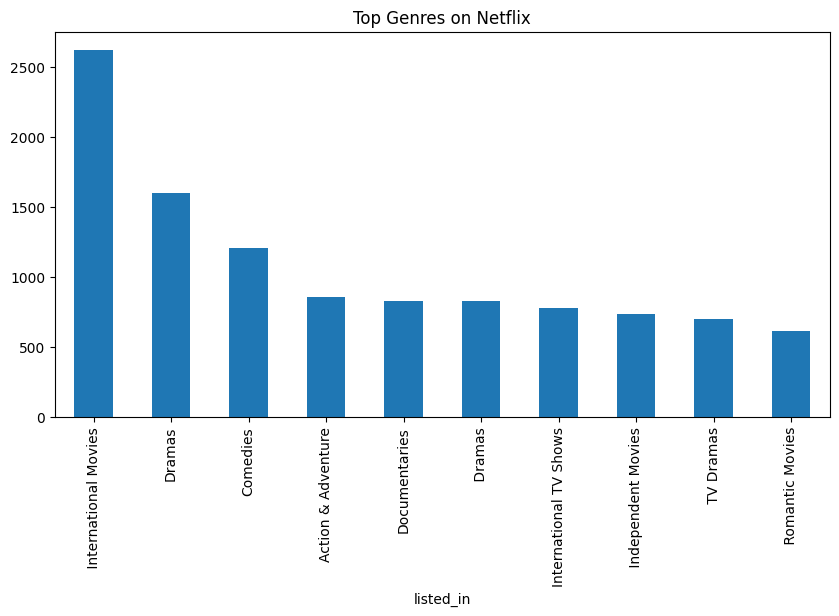

In [42]:
plt.figure(figsize=(10,5))

top_genres.plot(kind="bar")

plt.title("Top Genres on Netflix")

plt.savefig("images/top_genres.png")

plt.show()

### Key Insights Through the Graphs and Information

Insights:

1. Movies are more common than TV Shows.

2. United States contributes the highest amount of content.

3. TV-MA is the most common rating.

4. Netflix content increased rapidly after 2015.

5. International Movies is one of the largest genres.